# Итоговое задание: задачи №3 и №4

## MLForecast, NeuralForecast и финальный pipeline прогноза конечной температуры стали

* Задача №3: сравнить data-driven методы прогнозирования временного ряда через MLForecast и NeuralForecast.
* Задача №4: собрать воспроизводимый pipeline, провести тестирование и сформировать отчет.

Использую две постановки:

* MLForecast - reduction-подход: библиотека строит лаги и rolling-признаки, а ML-модели прогнозируют будущие значения;
* NeuralForecast - нейросетевой подход: модели NBEATS, NHITS и RNN обучаются на окнах временного ряда.

Реальная метка target_time нерегулярная, поэтому для моделей вводится регулярная шкала ds: один шаг соответствует одной следующей плавке. Реальные даты сохраняются для графиков и интерпретации.

### Импорты

In [69]:
from pathlib import Path
import json
import logging
import textwrap
import time
import types
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown

from mlforecast import MLForecast
from mlforecast.lag_transforms import ExpandingMean, RollingMean

from sklearn.base import clone
from sklearn.ensemble import ExtraTreesRegressor, HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from lightgbm import LGBMRegressor

import pytorch_lightning as pl

warnings.filterwarnings('ignore')
logging.getLogger().setLevel(logging.ERROR)
logging.getLogger('pytorch_lightning').setLevel(logging.ERROR)

sns.set_style('whitegrid')
sns.set(rc={'figure.figsize': (12, 4)})
pd.options.display.max_columns = 140

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

PROJECT_DIR = Path.cwd()
PREPARED_DIR = PROJECT_DIR / 'prepared_data'
FEATURES_PATH = PREPARED_DIR / 'eaf_temperature_heat_level_features.csv'
assert FEATURES_PATH.exists(), f'Не найден файл признаков: {FEATURES_PATH}. Сначала выполните ноутбук задачи №1.'

pl.utilities.distributed = types.SimpleNamespace(log=logging.getLogger('pytorch_lightning.utilities.distributed'))

def _append(self, other, ignore_index=False, **kwargs):
        return pd.concat([self, other], ignore_index=ignore_index, **kwargs)

pd.DataFrame.append = _append

import neuralforecast as neuralforecast_pkg
NEURALFORECAST_VERSION = getattr(neuralforecast_pkg, '__version__', 'unknown')

from neuralforecast.models.nbeats.nbeats import NBEATS as LegacyNBEATS
from neuralforecast.models.nbeats.nbeats import TimeSeriesLoader as LegacyTimeSeriesLoader
from neuralforecast.models.nbeats.nbeats import WindowsDataset as LegacyWindowsDataset
from neuralforecast.models.nhits.nhits import NHITS as LegacyNHITS
from neuralforecast.models.rnn.rnn import RNN as LegacyRNN
from neuralforecast.models.rnn.rnn import TimeSeriesDataset as LegacyTimeSeriesDataset

print('mlforecast: imported')
print('neuralforecast version:', NEURALFORECAST_VERSION)

mlforecast: imported
neuralforecast version: 0.1.0


## Загрузка данных

Загружаю файл eaf_temperature_heat_level_features.csv, сформированный на этапе EDA. В нем одна строка соответствует одной плавке, а признаки собраны из температурных измерений, трансформатора, кислорода/газа, углеродной инжекции, шихты, добавок и лагов целевой температуры.

In [70]:
feature_df = pd.read_csv(FEATURES_PATH)
feature_df['target_time'] = pd.to_datetime(feature_df['target_time'])
feature_df = feature_df.sort_values('heat_seq').reset_index(drop=True)

print('Размер ДФ:', feature_df.shape)
print('Период:', feature_df['target_time'].min(), '—', feature_df['target_time'].max())
print('Число плавок:', feature_df['HEATID'].nunique())
print('Пропуски всего:', int(feature_df.isna().sum().sum()))

feature_df.head()

Размер ДФ: (20827, 68)
Период: 2015-01-01 01:32:00 — 2018-07-29 09:16:00
Число плавок: 20827
Пропуски всего: 6621


,HEATID,target_time,target_temp,target_valo2_ppm,measurement_count,first_temp_time,first_temp,first_valo2_ppm,previous_temp_time,previous_temp,previous_valo2_ppm,minutes_first_to_target,minutes_previous_to_target,temp_delta_first_to_target,has_previous_temp,target_valo2_is_measured,heat_seq,transformer_rows,transformer_total_mw,transformer_mean_mw,transformer_max_mw,transformer_total_duration_min,transformer_mean_tap,transformer_max_tap,gaslance_rows,gaslance_time_start,gaslance_time_end,gaslance_o2_amount_max,gaslance_o2_amount_sum,gaslance_gas_amount_max,gaslance_gas_amount_sum,gaslance_o2_flow_max,gaslance_o2_flow_sum,gaslance_gas_flow_max,gaslance_gas_flow_sum,gaslance_o2_amount_mean,gaslance_gas_amount_mean,gaslance_o2_flow_mean,gaslance_gas_flow_mean,inj_rows,inj_time_start,inj_time_end,inj_inj_amount_carbon_max,inj_inj_amount_carbon_sum,inj_inj_flow_carbon_max,inj_inj_flow_carbon_sum,inj_inj_amount_carbon_mean,inj_inj_flow_carbon_mean,basket_rows,basket_total_amount,basket_mean_amount,basket_max_amount,basket_unique_materials,basket_time_start,basket_time_end,eaf_added_rows,eaf_added_total_amount,eaf_added_mean_amount,eaf_added_max_amount,eaf_added_unique_materials,eaf_added_time_start,eaf_added_time_end,target_temp_lag_1,target_temp_lag_2,target_temp_lag_3,target_temp_lag_5,target_temp_lag_10,target_temp_lag_20
0,5F0002,2015-01-01 01:32:00,1650.0,403.0,3,2015-01-01 01:30:00,1598.0,366.0,2015-01-01 01:31:00,1633.0,380.0,2.0,1.0,52.0,True,True,0,8.0,48.625,6.078125,29.125,1010.0,13.000000,15.0,248.0,2015-01-01 00:50:37.617,2015-01-01 01:31:58.289,3796.0,368154.0,1141.0,155556.0,5992.0,1030335.0,2562.0,398363.0,1484.491935,627.241935,4154.576613,1606.302419,202.0,2015-01-01 00:50:37.586,2015-01-01 01:31:58.289,1051.0,28543.0,122.0,5212.0,141.301980,25.801980,6.0,128590.0,21431.666667,49289.0,3.0,2015-01-01 00:51:00,2015-01-01 01:09:00,4.0,2763.0,690.75,835.0,4.0,2015-01-01 01:02:00,2015-01-01 01:29:00,NaN,NaN,NaN,NaN,NaN,NaN
1,5F0003,2015-01-01 02:18:00,1653.0,698.0,2,2015-01-01 02:17:00,1629.0,668.0,2015-01-01 02:17:00,1629.0,668.0,1.0,1.0,24.0,True,True,1,8.0,48.625,6.078125,28.750,2010.0,13.125000,15.0,236.0,2015-01-01 01:38:17.492,2015-01-01 02:17:57.476,3659.0,341620.0,1160.0,142793.0,6197.0,911545.0,2582.0,376131.0,1447.542373,605.055085,3862.478814,1593.775424,200.0,2015-01-01 01:38:17.476,2015-01-01 02:17:27.445,845.0,26451.0,114.0,5371.0,132.255000,26.855000,6.0,128826.0,21471.000000,49623.0,3.0,2015-01-01 01:39:00,2015-01-01 01:55:00,4.0,2758.0,689.50,831.0,4.0,2015-01-01 01:50:00,2015-01-01 02:15:00,1650.0,NaN,NaN,NaN,NaN,NaN
2,5F0004,2015-01-01 03:18:00,1636.0,700.0,2,2015-01-01 03:17:00,1636.0,700.0,2015-01-01 03:17:00,1636.0,700.0,1.0,1.0,0.0,True,True,2,13.0,47.375,3.644231,18.125,2060.0,13.230769,15.0,321.0,2015-01-01 02:23:12.664,2015-01-01 03:17:52.664,3469.0,542868.0,1156.0,230271.0,6383.0,1029755.0,2702.0,393419.0,1691.177570,717.355140,3207.959502,1225.604361,197.0,2015-01-01 02:23:12.648,2015-01-01 03:17:52.648,660.0,18777.0,108.0,4200.0,95.314721,21.319797,4.0,133715.0,33428.750000,73790.0,2.0,2015-01-01 02:24:00,2015-01-01 02:41:00,4.0,4055.0,1013.75,1810.0,4.0,2015-01-01 02:36:00,2015-01-01 03:18:00,1653.0,1650.0,NaN,NaN,NaN,NaN
3,5F0005,2015-01-01 04:07:00,1641.0,669.0,3,2015-01-01 04:05:00,1621.0,592.0,2015-01-01 04:06:00,1628.0,615.0,2.0,1.0,20.0,True,True,3,11.0,49.250,4.477273,27.875,2141.0,13.636364,15.0,247.0,2015-01-01 03:24:45.070,2015-01-01 04:06:55.070,3605.0,384778.0,1204.0,157238.0,6191.0,1032398.0,2546.0,391933.0,1557.805668,636.591093,4179.748988,1586.773279,201.0,2015-01-01 03:24:45.039,2015-01-01 04:06:55.055,692.0,25176.0,87.0,4367.0,125.253731,21.726368,6.0,129233.0,21538.833333,49633.0,3.0,2015-01-01 03:25:00,2015-01-01 03:43:00,4.0,2753.0,688.25,829.0,4.0,2015-01-01 03:36:00,2015-01-01 04:04:00,1636.0,1653.0,1650.0,NaN,NaN,NaN
4,5F0006,2015-01-01 04:57:00,1651.0,789.0,4,2015-01-01 04:53:00,1620.0,624.0,2015-01-01 04:55:00,1611.0,622.0,4.0,2.0,31.0,True,True,4,11.0,49.875,4.534

## Постановка ML/DL задачи

Прогнозируем конечную температуру **target_temp** на следующий горизонт плавок.

Чтобы снизить риск утечки, исключу некоторые данные:

* target_temp из признаков;
* целевое измерение: **target_valo2_ppm**, **target_valo2_is_measured**;
* признаки, напрямую построенные от целевого измерения:     
  - **temp_delta_first_to_target**, длительности до целевого момента и 
  - **measurement_count**;
* **target_temp_lag_** из X_df, потому что MLForecast должен строить лаги рекурсивно сам;
* оставляю только плавки с предыдущим температурным измерением (**has_previous_temp = True**).

In [72]:
LEAKAGE_COLS = [ 'target_temp',
                 'target_valo2_ppm',
                 'target_valo2_is_measured',
                 'temp_delta_first_to_target',
                 'minutes_first_to_target',
                 'minutes_previous_to_target',
                 'measurement_count',]

ID_TIME_COLS = ['HEATID', 'target_time', 'first_temp_time', 'previous_temp_time']

object_cols = feature_df.select_dtypes(include='object').columns.tolist()
target_history_cols = [col for col in feature_df.columns if col.startswith('target_temp_lag_')]
exclude_cols = set(LEAKAGE_COLS + ID_TIME_COLS + object_cols + target_history_cols)

model_df = feature_df.copy()
model_df = model_df[model_df['has_previous_temp'].fillna(False)].copy().reset_index(drop=True)

for col in model_df.select_dtypes(include='bool').columns:
    model_df[col] = model_df[col].astype(int)

feature_cols = [ col for col in model_df.columns
    if col not in exclude_cols and pd.api.types.is_numeric_dtype(model_df[col])]

target_col = 'target_temp'
UNIQUE_ID = 'EAF_final_temperature'
FREQ = 'h'

model_df['unique_id'] = UNIQUE_ID
model_df['ds'] = pd.date_range( start='2015-01-01', 
                                periods=len(model_df), 
                                freq=FREQ )

mlf_df = model_df[['unique_id', 'ds', target_col] + 
                   feature_cols].rename(columns={target_col: 'y'}).copy()

nf_df = model_df[['unique_id', 'ds', target_col]].rename(columns={target_col: 'y'}).copy()

print('Размер после фильтрации:', model_df.shape)
print('Число доп. признаков для MLForecast:', len(feature_cols))
print('Исключены как утечки/служебные:', sorted(exclude_cols.intersection(feature_df.columns)))

model_df[['HEATID', 'target_time', 'ds', 'target_temp'] + feature_cols[:8]].head()

Размер после фильтрации: (19736, 70)
Число доп. признаков для MLForecast: 43
Исключены как утечки/служебные: ['HEATID', 'basket_time_end', 'basket_time_start', 'eaf_added_time_end', 'eaf_added_time_start', 'first_temp_time', 'gaslance_time_end', 'gaslance_time_start', 'inj_time_end', 'inj_time_start', 'measurement_count', 'minutes_first_to_target', 'minutes_previous_to_target', 'previous_temp_time', 'target_temp', 'target_temp_lag_1', 'target_temp_lag_10', 'target_temp_lag_2', 'target_temp_lag_20', 'target_temp_lag_3', 'target_temp_lag_5', 'target_time', 'target_valo2_is_measured', 'target_valo2_ppm', 'temp_delta_first_to_target']


,HEATID,target_time,ds,target_temp,first_temp,first_valo2_ppm,previous_temp,previous_valo2_ppm,has_previous_temp,heat_seq,transformer_rows,transformer_total_mw
0,5F0002,2015-01-01 01:32:00,2015-01-01 00:00:00,1650.0,1598.0,366.0,1633.0,380.0,1,0,8.0,48.625
1,5F0003,2015-01-01 02:18:00,2015-01-01 01:00:00,1653.0,1629.0,668.0,1629.0,668.0,1,1,8.0,48.625
2,5F0004,2015-01-01 03:18:00,2015-01-01 02:00:00,1636.0,1636.0,700.0,1636.0,700.0,1,2,13.0,47.375
3,5F0005,2015-01-01 04:07:00,2015-01-01 03:00:00,1641.0,1621.0,592.0,1628.0,615.0,1,3,11.0,49.250
4,5F0006,2015-01-01 04:57:00,2015-01-01 04:00:00,1651.0,1620.0,624.0,1611.0,622.0,1,4,11.0,49.875


## Хронологическое разбиение

Для временных рядов нельзя случайно перемешивать наблюдения. Используем хронологическое разбиение: ранние плавки для обучения, следующий участок для validation и последний участок для test.

Горизонт выбран **72** плавки. Это сопоставимо с горизонтом задачи №2, где backtesting также оценивался на **72** наблюдениях.

In [ ]:
FORECAST_HORIZON = 72
TEST_SIZE = FORECAST_HORIZON
VAL_SIZE = FORECAST_HORIZON
STAT_BENCHMARK_MAE = 13.86

n = len(model_df)
# Проверяю, что после выделения validation и 
# test остается достаточно данных для обучения модели.

assert n > TEST_SIZE + VAL_SIZE + 1000, 'Слишком мало строк для выбранного разбиения.'

train_df = model_df.iloc[: n - VAL_SIZE - TEST_SIZE].copy()
val_df = model_df.iloc[n - VAL_SIZE - TEST_SIZE : n - TEST_SIZE].copy()
test_df = model_df.iloc[n - TEST_SIZE :].copy()

train_mlf = mlf_df.iloc[: n - VAL_SIZE - TEST_SIZE].copy()
val_mlf = mlf_df.iloc[n - VAL_SIZE - TEST_SIZE : n - TEST_SIZE].copy()
test_mlf = mlf_df.iloc[n - TEST_SIZE :].copy()
train_val_mlf = pd.concat([train_mlf, val_mlf], ignore_index=True)

train_nf = nf_df.iloc[: n - VAL_SIZE - TEST_SIZE].copy()
val_nf = nf_df.iloc[n - VAL_SIZE - TEST_SIZE : n - TEST_SIZE].copy()
test_nf = nf_df.iloc[n - TEST_SIZE :].copy()
train_val_nf = pd.concat([train_nf, val_nf], ignore_index=True)

split_table = pd.DataFrame({
    'part': ['train', 'validation', 'test'],
    'rows': [len(train_df), len(val_df), len(test_df)],
    'time_start': [train_df['target_time'].min(), val_df['target_time'].min(), test_df['target_time'].min()],
    'time_end': [train_df['target_time'].max(), val_df['target_time'].max(), test_df['target_time'].max()],
    'ds_start': [train_df['ds'].min(), val_df['ds'].min(), test_df['ds'].min()],
    'ds_end': [train_df['ds'].max(), val_df['ds'].max(), test_df['ds'].max()],})

split_table

,part,rows,time_start,time_end,ds_start,ds_end
0,train,19592,2015-01-01 01:32:00,2018-07-09 21:46:00,2015-01-01 00:00:00,2017-03-27 07:00:00
1,validation,72,2018-07-09 23:27:00,2018-07-14 01:30:00,2017-03-27 08:00:00,2017-03-30 07:00:00
2,test,72,2018-07-14 08:45:00,2018-07-29 09:16:00,2017-03-30 08:00:00,2017-04-02 07:00:00


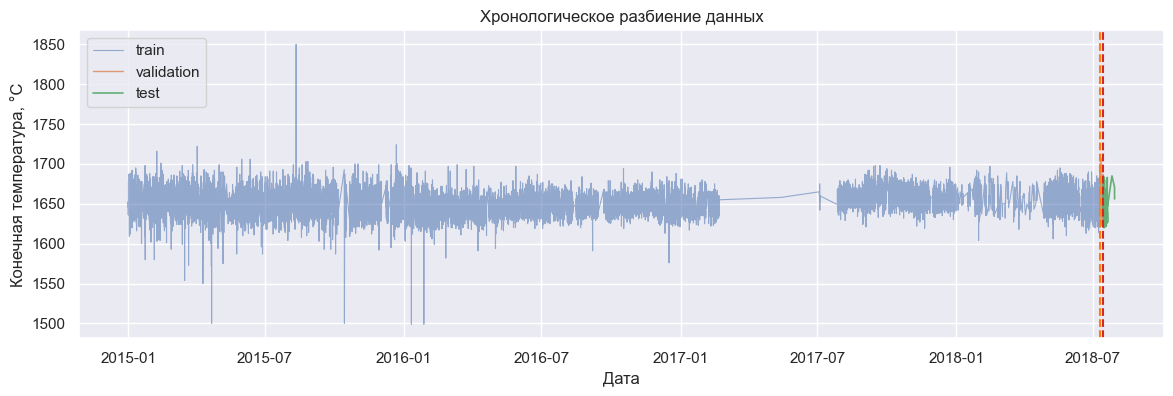

In [46]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(train_df['target_time'], train_df['target_temp'], linewidth=0.8, alpha=0.55, label='train')
ax.plot(val_df['target_time'], val_df['target_temp'], linewidth=1.0, alpha=0.8, label='validation')
ax.plot(test_df['target_time'], test_df['target_temp'], linewidth=1.2, alpha=0.9, label='test')
ax.axvline(val_df['target_time'].min(), color='tab:orange', linestyle='--')
ax.axvline(test_df['target_time'].min(), color='tab:red', linestyle='--')
ax.set_title('Хронологическое разбиение данных')
ax.set_xlabel('Дата')
ax.set_ylabel('Конечная температура, °C')
ax.legend()
plt.show()

## Метрики качества

In [ ]:
def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.sqrt(np.mean((y_true - y_pred) ** 2))


def mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100


def smape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    return np.mean(np.abs(y_true - y_pred) / denominator) * 100


def regression_metrics(y_true, y_pred):
    return { 'MAE': mean_absolute_error(y_true, y_pred),
             'RMSE': rmse(y_true, y_pred),
             'MAPE_%': mape(y_true, y_pred),
             'sMAPE_%': smape(y_true, y_pred),
             'R2': r2_score(y_true, y_pred),
             'n_obs': len(y_true),}

## MLForecast

Сравниваю 5 ML-моделей: Ridge, RandomForest, ExtraTrees, HistGradientBoosting и LightGBM.

In [ ]:
LAGS = [1, 2, 3, 6, 12, 24, 48]
LAG_TRANSFORMS = {1: [RollingMean(window_size=3), 
                      RollingMean(window_size=12), 
                      RollingMean(window_size=24), 
                      ExpandingMean()],
                  24: [RollingMean(window_size=3)],}

def make_ml_models():
    scaled_preprocess = Pipeline(steps=[('imputer', 
                                         SimpleImputer(strategy='median')),
                                        ('scaler', 
                                         StandardScaler()), ])
    plain_preprocess = Pipeline(steps=[('imputer', 
                                        SimpleImputer(strategy='median')),])

    return {'MLF_Ridge': Pipeline([('preprocess', scaled_preprocess),
                                   ('model', Ridge(alpha=10.0)),]),

            'MLF_RandomForest': Pipeline([('preprocess', plain_preprocess),
                                        ('model', 
                                         RandomForestRegressor( n_estimators=120, 
                                                                max_depth=14, 
                                                                min_samples_leaf=5,                                                                
                                                                random_state=RANDOM_STATE, 
                                                                n_jobs=-1, )), ]),
            
            'MLF_ExtraTrees': Pipeline([('preprocess', plain_preprocess),
                                         ('model', 
                                          ExtraTreesRegressor(n_estimators=150,
                                                              max_depth=16, 
                                                              min_samples_leaf=4,
                                                              random_state=RANDOM_STATE, 
                                                              n_jobs=-1, )), ]),
            'MLF_HistGradientBoosting': Pipeline([('preprocess', plain_preprocess),
                                                   ('model', 
                                                    HistGradientBoostingRegressor(max_iter=250, 
                                                                                  learning_rate=0.05, 
                                                                                  l2_regularization=0.05,
                                                                                  early_stopping=True, 
                                                                                  random_state=RANDOM_STATE, )), ]),
            'MLF_LightGBM': Pipeline([('preprocess', plain_preprocess),
                                      ('model', LGBMRegressor(n_estimators=250, 
                                                              learning_rate=0.03, 
                                                              num_leaves=31, 
                                                              subsample=0.9, 
                                                              colsample_bytree=0.9,
                                                              random_state=RANDOM_STATE, 
                                                              verbose=-1, )), ]),
    }

def make_mlforecast(models=None):
    return MLForecast( models=make_ml_models() if models is None else models,
                       freq=FREQ,
                       lags=LAGS,
                       lag_transforms=LAG_TRANSFORMS,
                       num_threads=4, )

ml_models = make_ml_models()
list(ml_models.keys())

['MLF_Ridge',
 'MLF_RandomForest',
 'MLF_ExtraTrees',
 'MLF_HistGradientBoosting',
 'MLF_LightGBM']

In [ ]:
ml_model_names = list(ml_models.keys())

mlf_train = make_mlforecast()
start_time = time.perf_counter()
mlf_train.fit(train_mlf, static_features=[])
mlf_val_fit_seconds = time.perf_counter() - start_time

val_pred_mlf = mlf_train.predict(VAL_SIZE, X_df=val_mlf.drop(columns='y'))

mlf_train_val = make_mlforecast()
start_time = time.perf_counter()
mlf_train_val.fit(train_val_mlf, static_features=[])
mlf_test_fit_seconds = time.perf_counter() - start_time

start_time = time.perf_counter()
test_pred_mlf = mlf_train_val.predict(TEST_SIZE, X_df=test_mlf.drop(columns='y'))
mlf_predict_seconds = time.perf_counter() - start_time

val_eval_mlf = val_mlf[['unique_id', 'ds', 'y']].merge(val_pred_mlf, on=['unique_id', 'ds'], how='left')
test_eval_mlf = test_mlf[['unique_id', 'ds', 'y']].merge(test_pred_mlf, on=['unique_id', 'ds'], how='left')

ml_rows = []
for name in ml_model_names:
    row = { 'model': name,
            'family': 'MLForecast',
            'api': 'MLForecast',
            'fit_seconds': mlf_val_fit_seconds + mlf_test_fit_seconds,
            'predict_seconds': mlf_predict_seconds, }

    row.update({f'val_{k}': v for k, v in regression_metrics(val_eval_mlf['y'], val_eval_mlf[name]).items()})
    row.update(regression_metrics(test_eval_mlf['y'], test_eval_mlf[name]))
    ml_rows.append(row)

ml_metrics = pd.DataFrame(ml_rows).sort_values('MAE').reset_index(drop=True)
ml_metrics

,model,family,api,fit_seconds,predict_seconds,val_MAE,val_RMSE,val_MAPE_%,val_sMAPE_%,val_R2,val_n_obs,MAE,RMSE,MAPE_%,sMAPE_%,R2,n_obs
0,MLF_LightGBM,MLForecast,MLForecast,90.575167,19.002927,11.189001,14.744679,0.675164,0.676536,0.186527,72,11.660782,14.705905,0.706497,0.706082,0.239159,72
1,MLF_HistGradientBoosting,MLForecast,MLForecast,90.575167,19.002927,11.045849,14.763169,0.666115,0.667789,0.184486,72,11.682502,14.689647,0.707572,0.707303,0.240841,72
2,MLF_ExtraTrees,MLForecast,MLForecast,90.575167,19.002927,11.552821,14.906953,0.696691,0.698352,0.168523,72,12.141717,14.940845,0.734940,0.735065,0.214655,72
3,MLF_RandomForest,MLForecast,MLForecast,90.575167,19.002927,11.357176,15.045302,0.684890,0.686582,0.153018,72,12.240161,15.197474,0.741145,0.741020,0.187445,72
4,MLF_Ridge,MLForecast,MLForecast,90.575167,19.002927,11.846775,15.337936,0.713966,0.716209,0.119750,72,13.263914,17.320120,0.801926,0.803066,-0.055387,72


Выводы по блоку MLForecast:

Лучшей моделью по основной метрике MAE стала MLF_LightGBM: ошибка на test составляет 11.66 °C. Это лучший результат среди MLForecast-моделей.

MLF_HistGradientBoosting практически не уступает LightGBM: MAE = 11.68 °C, а по RMSE и R2 она даже чуть лучше. Разница между ними очень маленькая, поэтому обе модели можно считать сопоставимыми.

Все ансамблевые модели деревьев дали качество лучше линейной Ridge. Это говорит о том, что зависимость конечной температуры от лагов и технологических признаков, скорее всего, нелинейная.

MLF_Ridge показала результат хуже: MAE = 13.26 °C, RMSE = 17.32 °C, 
R2 = -0.055. Отрицательный R2 означает, что на тестовом участке модель хуже объясняет изменчивость температуры, чем простой прогноз средним значением.

По сравнению со статистическим бенчмарком из задачи №2, где ARIMA давала примерно MAE ≈ 13.86 °C, лучшая MLForecast-модель улучшила ошибку примерно на 2.2 °C, то есть примерно на 16%. Таким образом, ехнологические признаки и лаги  добавили полезную информацию.

Значения MAPE и sMAPE около 0.7% выглядят небольшими, потому что температура измеряется около 1600-1700 °C. Поэтому для интерпретации здесь лучше ориентироваться именно на MAE в градусах.

R2 у лучших моделей около 0.24, то есть модель объясняет только часть вариативности температуры. Это нормально для промышленного процесса с шумом, но показывает, что точность прогноза ограничена качеством и полнотой доступных признаков.

fit_seconds и predict_seconds одинаковые во всех строках, потому что MLForecast обучал и прогнозировал все модели в одном объекте. Это общее время блока, а не индивидуальное время каждой модели.

Итог: для дальнейшей задачи №4 логично выбрать MLF_LightGBM как финальную модель по минимальному MAE, при этом отметить, что MLF_HistGradientBoosting является почти равноценной альтернативой.

## NeuralForecast

Используются классы NBEATS, NHITS и RNN. Целевой ряд стандартизируется на обучающем участке, а прогноз затем возвращается в градусы Цельсия.

In [74]:
NF_INPUT_SIZE = 48
NF_MAX_EPOCHS = 5
NF_BATCH_SIZE = 64
NF_TRAIN_TAIL = 5000

nf_model_configs = [ {'model': 'NF_NBEATS', 'kind': 'NBEATS'},
                     {'model': 'NF_NHITS', 'kind': 'NHITS'},
                     {'model': 'NF_RNN_LSTM', 'kind': 'RNN'},]

def make_legacy_nf_model(kind, input_size, horizon):

    if kind == 'NBEATS':

        return LegacyNBEATS(n_time_in=input_size, 
                            n_time_out=horizon, 
                            n_x=0, 
                            n_s=0,
                            shared_weights=False, 
                            activation='ReLU', 
                            initialization='lecun_normal',
                            stack_types=['identity'], 
                            n_blocks=[1], 
                            n_layers=[2], 
                            n_mlp_units=[[64, 64]],
                            n_harmonics=5, 
                            n_polynomials=5, 
                            n_x_hidden=[0], 
                            n_s_hidden=[0],
                            batch_normalization=False, 
                            dropout_prob_theta=0.0, 
                            learning_rate=1e-3,
                            lr_decay=0.5, 
                            lr_decay_step_size=5, 
                            weight_decay=0.0,
                            loss_train='MAE', 
                            loss_hypar=0.0, 
                            loss_valid='MAE',
                            frequency=FREQ, 
                            random_seed=RANDOM_STATE, )

    if kind == 'NHITS':
        return LegacyNHITS( n_time_in=input_size, 
                           n_time_out=horizon, 
                           n_x=0, 
                           n_s=0,
                           shared_weights=False, 
                           activation='ReLU', 
                           initialization='lecun_normal',
                           stack_types=['identity'], 
                           n_blocks=[1], 
                           n_layers=[2], 
                           n_mlp_units=[[64, 64]],
                           n_x_hidden=0, 
                           n_s_hidden=0, 
                           n_pool_kernel_size=[2], 
                           n_freq_downsample=[1],
                           pooling_mode='max', 
                           interpolation_mode='linear',
                           batch_normalization=False, 
                           dropout_prob_theta=0.0, 
                           learning_rate=1e-3,
                           lr_decay=0.5, 
                           lr_decay_step_size=5, 
                           weight_decay=0.0,
                           loss_train='MAE', 
                           loss_hypar=0.0, 
                           loss_valid='MAE',
                           frequency=FREQ, 
                           random_seed=RANDOM_STATE, )

    if kind == 'RNN':
        return LegacyRNN(input_size=input_size, 
                         output_size=horizon,
                         n_x=0, 
                         n_s=0,
                         sample_freq=1, 
                         cell_type='LSTM', 
                         state_hsize=32, 
                         dilations=[[1, 2]],
                         add_nl_layer=False, 
                         learning_rate=1e-3, 
                         lr_scheduler_step_size=10,
                         lr_decay=0.9, 
                         gradient_eps=1e-8, 
                         gradient_clipping_threshold=20.0,
                         weight_decay=0.0, 
                         noise_std=0.001,
                         loss_train='MAE', 
                         loss_valid='MAE', loss_hypar=0.0,
                         frequency=FREQ, 
                         random_seed=RANDOM_STATE,)

def make_nf_trainer():
    return pl.Trainer( max_epochs=NF_MAX_EPOCHS,
                       logger=False,
                       enable_checkpointing=False,
                       enable_progress_bar=False, )

def train_predict_legacy_nf(config, history_df, horizon):

    history_tail = history_df[['unique_id', 'ds', 'y']].tail(NF_TRAIN_TAIL).copy()
    y_mean = float(history_tail['y'].mean())
    y_std = float(history_tail['y'].std())
    y_std = y_std if y_std != 0 else 1.0

    scaled_history = history_tail.copy()
    scaled_history['y'] = (scaled_history['y'] - y_mean) / y_std
    model = make_legacy_nf_model(config['kind'], NF_INPUT_SIZE, horizon)

    if config['kind'] in ['NBEATS', 'NHITS']:
        dataset = LegacyWindowsDataset( Y_df=scaled_history,
                                        input_size=NF_INPUT_SIZE,
                                        output_size=horizon,
                                        complete_windows=True,
                                        verbose=False,)
    else:
        dataset = LegacyTimeSeriesDataset( Y_df=scaled_history,
                                           input_size=NF_INPUT_SIZE,
                                           output_size=horizon,
                                           verbose=False, )

    '''  shuffle=True используется для 
        перемешивания не дат в исходном ряду, а  окон внутри train-части.
        То есть сначала из train-ряда создаются окна вида:
        [прошлые 48 плавок] -> [следующие 72 плавки]
        А потом эти окна подаются нейросети в случайном порядке

        Утечки здесь нет, потому что: 
            - validation/test в обучение не попадают;
            - каждое окно внутри train строится только из 
               доступной обучающей истории;
            - перемешивается порядок подачи окон модели, 
              а не временное разбиение данных.
    '''
    loader = LegacyTimeSeriesLoader(dataset=dataset, 
                                    batch_size=NF_BATCH_SIZE, 
                                    shuffle=True)
    trainer = make_nf_trainer()

    start_time = time.perf_counter()
    trainer.fit(model, loader)
    fit_seconds = time.perf_counter() - start_time

    start_time = time.perf_counter()

    forecast_scaled = model.forecast(scaled_history.copy(), 
                                     batch_size=1, 
                                     trainer=trainer)
    
    predict_seconds = time.perf_counter() - start_time

    forecast = forecast_scaled[['unique_id', 'ds', 'y']].copy()
    forecast['y'] = forecast['y'] * y_std + y_mean
    forecast = forecast.rename(columns={'y': config['model']})
    return forecast, fit_seconds, predict_seconds, model


print('Конфиг для NeuralForecast:', [cfg['model'] for cfg in nf_model_configs])

Конфиг для NeuralForecast: ['NF_NBEATS', 'NF_NHITS', 'NF_RNN_LSTM']


In [ ]:
nf_rows = []
fitted_nf_models = {}
nf_prediction_frames = []

for cfg in nf_model_configs:
    start_total = time.perf_counter()
    try:
        val_pred_nf, val_fit_seconds, val_predict_seconds, _ = train_predict_legacy_nf(cfg, train_nf, VAL_SIZE)
        test_pred_nf, test_fit_seconds, test_predict_seconds, fitted_model = train_predict_legacy_nf(cfg, train_val_nf, TEST_SIZE)

        val_eval_nf = val_nf[['unique_id', 'ds', 'y']].merge(val_pred_nf, on=['unique_id', 'ds'], how='left')
        test_eval_nf = test_nf[['unique_id', 'ds', 'y']].merge(test_pred_nf, on=['unique_id', 'ds'], how='left')

        row = { 'model': cfg['model'],
                'family': 'NeuralForecast',
                'api': f'legacy {NEURALFORECAST_VERSION}',
                'kind': cfg['kind'],
                'fit_seconds': val_fit_seconds + test_fit_seconds,
                'predict_seconds': val_predict_seconds + test_predict_seconds,
                'error': None,}

        row.update({f'val_{k}': v for k, v in regression_metrics(val_eval_nf['y'], val_eval_nf[cfg['model']]).items()})
        row.update(regression_metrics(test_eval_nf['y'], test_eval_nf[cfg['model']]))

        nf_rows.append(row)
        fitted_nf_models[cfg['model']] = fitted_model
        nf_prediction_frames.append(test_pred_nf)

    except Exception as exc:
        nf_rows.append({
            'model': cfg['model'],
            'family': 'NeuralForecast',
            'api': f'legacy {NEURALFORECAST_VERSION}',
            'kind': cfg['kind'],
            'fit_seconds': time.perf_counter() - start_total,
            'predict_seconds': np.nan,
            'MAE': np.nan,
            'RMSE': np.nan,
            'MAPE_%': np.nan,
            'sMAPE_%': np.nan,
            'R2': np.nan,
            'n_obs': 0,
            'error': repr(exc),
        })
        print(f"Ошибка NeuralForecast для {cfg['model']}: {exc}")

nf_metrics = pd.DataFrame(nf_rows).sort_values('MAE', na_position='last').reset_index(drop=True)
nf_metrics

┏━━━┳━━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type    ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ _NBEATS │ 15.1 K │ train │     0 │
└───┴───────┴─────────┴────────┴───────┴───────┘

Trainable params: 15.1 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 15.1 K                                                                                               
Total estimated model params size (MB): 0.060                                                                      
Modules in train mode: 9                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

┏━━━┳━━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type    ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ _NBEATS │ 15.1 K │ train │     0 │
└───┴───────┴─────────┴────────┴───────┴───────┘

Trainable params: 15.1 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 15.1 K                                                                                               
Total estimated model params size (MB): 0.060                                                                      
Modules in train mode: 9                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

┏━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type   ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ _NHITS │ 13.6 K │ train │     0 │
└───┴───────┴────────┴────────┴───────┴───────┘

...

┏━━━┳━━━━━━━┳━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ _RNN │ 21.3 K │ train │     0 │
└───┴───────┴──────┴────────┴───────┴───────┘

Trainable params: 21.3 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 21.3 K                                                                                               
Total estimated model params size (MB): 0.085                                                                      
Modules in train mode: 7                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

┏━━━┳━━━━━━━┳━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ _RNN │ 21.3 K │ train │     0 │
└───┴───────┴──────┴────────┴───────┴───────┘

Trainable params: 21.3 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 21.3 K                                                                                               
Total estimated model params size (MB): 0.085                                                                      
Modules in train mode: 7                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

,model,family,api,kind,fit_seconds,predict_seconds,error,val_MAE,val_RMSE,val_MAPE_%,val_sMAPE_%,val_R2,val_n_obs,MAE,RMSE,MAPE_%,sMAPE_%,R2,n_obs
0,NF_RNN_LSTM,NeuralForecast,legacy 0.1.0,RNN,4.417217,1.080983,None,14.295232,17.160289,0.865137,0.864180,-0.101847,72,13.844108,17.353596,0.840325,0.838087,-0.059471,72
1,NF_NBEATS,NeuralForecast,legacy 0.1.0,NBEATS,0.345167,0.620976,None,13.575636,18.045466,0.816457,0.820832,-0.218452,72,15.774492,18.880345,0.951129,0.955340,-0.254094,72
2,NF_NHITS,NeuralForecast,legacy 0.1.0,NHITS,0.334804,0.672438,None,13.461127,17.982535,0.809647,0.813863,-0.209969,72,15.863481,18.940683,0.956689,0.960742,-0.262122,72


По NeuralForecast результаты такие:

Лучшей NeuralForecast моделью стала NF_RNN_LSTM: 
на тесте она дала MAE = 13.84 °C, RMSE = 17.35 °C.

NF_RNN_LSTM заметно лучше, чем NF_NBEATS и NF_NHITS на test:

NF_NBEATS: MAE = 15.77 °C;
NF_NHITS: MAE = 15.86 °C.

При этом все модели NeuralForecast  проиграли лучшим моделям MLForecast. 
Для сравнения: MLF_LightGBM дал MAE = 11.66 °C, то есть примерно на **2.18 °C** лучше, чем NF_RNN_LSTM.

NF_RNN_LSTM почти совпал со статистическим benchmark ARIMA из задачи №2 (MAE ≈ 13.86 °C), но не улучшил его существенно.

У всех NeuralForecast-моделей R2 отрицательный:

NF_RNN_LSTM: R2 = -0.059;
NF_NBEATS: R2 = -0.254;
NF_NHITS: R2 = -0.262.

Это означает, что на тестовом участке нейросетевые модели объясняют изменчивость температуры хуже, чем простой прогноз средним значением.

NBEATS и NHITS выглядят переобученными или нестабильными: на валидации у них MAE ≈ 13.4 °C, а на тесте ошибка ухудшается до 15.8 °C.

Итог: в рамках текущей настройки NeuralForecast не дал преимущества. Лучшей моделью DL можно считать NF_RNN_LSTM, но для финального пайплайна оставлю MLF_LightGBM, так как он дает существенно меньшую ошибку и лучше использует технологические признаки.

## Сравнение MLForecast и NeuralForecast

In [ ]:
all_metrics = pd.concat([ml_metrics, nf_metrics], ignore_index=True, sort=False)
all_metrics = all_metrics.sort_values('MAE', na_position='last').reset_index(drop=True)
all_metrics['beats_stat_benchmark'] = all_metrics['MAE'] < STAT_BENCHMARK_MAE

all_predictions = pd.DataFrame({'HEATID': test_df['HEATID'].to_numpy(),
                                'target_time': test_df['target_time'].to_numpy(),
                                'ds': test_df['ds'].to_numpy(),
                                'y_true': test_df['target_temp'].to_numpy(),
                                'previous_temp_baseline': test_df['previous_temp'].astype(float).to_numpy(),})

for name in ml_model_names:
    all_predictions[name] = test_eval_mlf[name].to_numpy()

for pred_frame in nf_prediction_frames:
    pred_col = [col for col in pred_frame.columns if col not in ['unique_id', 'ds']][0]
    all_predictions = all_predictions.merge(pred_frame[['ds', pred_col]], 
                                            on='ds', 
                                            how='left')

all_metrics

,model,family,api,fit_seconds,predict_seconds,val_MAE,val_RMSE,val_MAPE_%,val_sMAPE_%,val_R2,val_n_obs,MAE,RMSE,MAPE_%,sMAPE_%,R2,n_obs,kind,error,beats_stat_benchmark
0,MLF_LightGBM,MLForecast,MLForecast,90.575167,19.002927,11.189001,14.744679,0.675164,0.676536,0.186527,72,11.660782,14.705905,0.706497,0.706082,0.239159,72,NaN,NaN,True
1,MLF_HistGradientBoosting,MLForecast,MLForecast,90.575167,19.002927,11.045849,14.763169,0.666115,0.667789,0.184486,72,11.682502,14.689647,0.707572,0.707303,0.240841,72,NaN,NaN,True
2,MLF_ExtraTrees,MLForecast,MLForecast,90.575167,19.002927,11.552821,14.906953,0.696691,0.698352,0.168523,72,12.141717,14.940845,0.734940,0.735065,0.214655,72,NaN,NaN,True
3,MLF_RandomForest,MLForecast,MLForecast,90.575167,19.002927,11.357176,15.045302,0.684890,0.686582,0.153018,72,12.240161,15.197474,0.741145,0.741020,0.187445,72,NaN,NaN,True
4,MLF_Ridge,MLForecast,MLForecast,90.575167,19.002927,11.846775,15.337936,0.713966,0.716209,0.119750,72,13.263914,17.320120,0.801926,0.803066,-0.055387,72,NaN,NaN,True
5,NF_RNN_LSTM,NeuralForecast,legacy 0.1.0,0.773392,0.638734,14.295232,17.160289,0.865137,0.864180,-0.101847,72,13.844108,17.353596,0.840325,0.838087,-0.059471,72,RNN,None,True
6,NF_NBEATS,NeuralForecast,legacy 0.1.0,0.367082,0.648759,13.575636,18.045466,0.816457,0.820832,-0.218452,72,15.774492,18.880345,0.951129,0.955340,-0.254094,72,NBEATS,None,False
7,NF_NHITS,NeuralForecast,legacy 0.1.0,0.341216,0.646245,13.461127,17.982535,0.809647,0.813863,-0.209969,72,15.863481,18.940683,0.956689,0.960742,-0.262122,72,NHITS,None,False


По итоговому сравнению MLForecast и NeuralForecast видно следующее:

Лучший результат дала модель MLF_LightGBM: 

MAE = 11.66 °C, RMSE = 14.71 °C, R2 = 0.239.

Все модели MLForecast оказались лучше всех моделей NeuralForecast по MAE. 

Даже худшая MLForecast-модель MLF_Ridge с MAE = 13.26 °C немного лучше лучшей NeuralForecast-модели NF_RNN_LSTM с MAE = 13.84 °C.

Модели MLForecast дали немного лучший результат по сравнению с ARIMA из задачи №2 (MAE ≈ 13.86 °C). 

Флаг beats_stat_benchmark = True у всех MLForecast-моделей.

Из NeuralForecast только NF_RNN_LSTM смогла приблизиться к ARIMA и формально немного улучшить бенчмарк: MAE = 13.84 °C против 13.86 °C.
Но улучшение минимальное и практически незначимое.

NF_NBEATS и NF_NHITS показали худшее качество: MAE ≈ 15.8 °C, отрицательный R2, и они не превзошли статистический benchmark.

Главная причина преимущества MLForecast - использование технологических дополнительныйх внешних признаков вместе с лагами температуры. 

NeuralForecast в текущей постановке обучался только на самом ряде target_temp, поэтому информации у него меньше.

По R2 лучшие значения тоже у MLForecast: около 0.24. У всех NeuralForecast моделей R2 отрицательный, то есть они хуже объясняют вариативность температуры на тестовом участке.

Итог: для финального pipeline в задаче №4 выбираю  MLF_LightGBM. Она дает минимальную ошибку, превосходит статистический бенчмарк и лучше использует доступные технологические признаки.

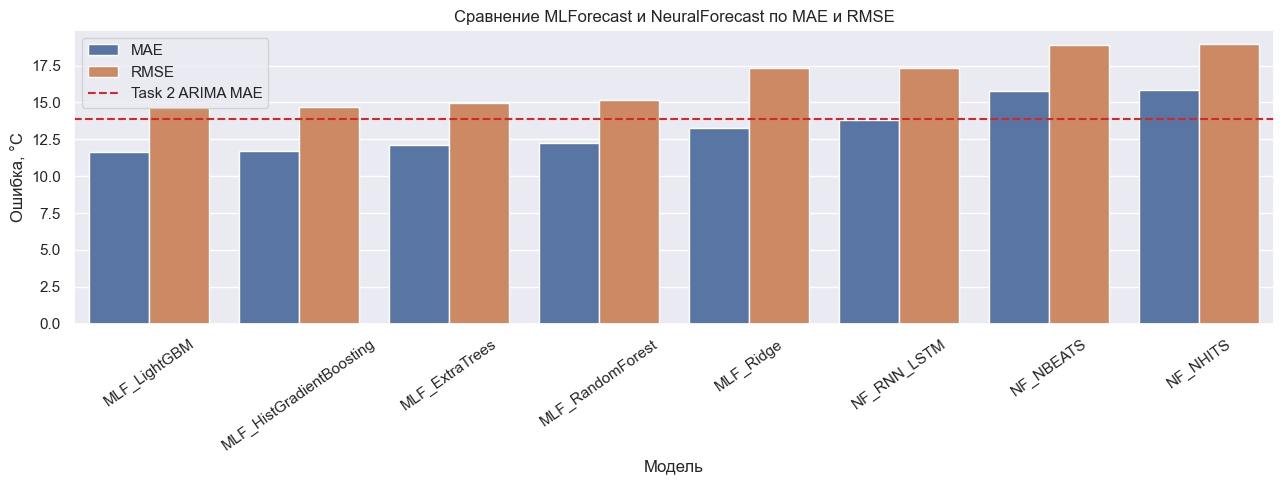

In [ ]:
plot_metrics = all_metrics.dropna(subset=['MAE']).melt(
    id_vars=['model', 'family'],
    value_vars=['MAE', 'RMSE'],
    var_name='metric',
    value_name='value',
)

fig, ax = plt.subplots(figsize=(13, 5))
sns.barplot(data=plot_metrics, x='model', y='value', hue='metric', ax=ax)
ax.axhline(STAT_BENCHMARK_MAE, color='tab:red', linestyle='--', label='Task 2 ARIMA MAE')
ax.set_title('Сравнение MLForecast и NeuralForecast по MAE и RMSE')
ax.set_xlabel('Модель')
ax.set_ylabel('Ошибка, °C')
ax.tick_params(axis='x', rotation=35)
ax.legend()
plt.tight_layout()
plt.show()

По гистограмме видно:

Лучшие результаты находятся слева: MLF_LightGBM и MLF_HistGradientBoosting имеют самые низкие столбцы MAE и RMSE.

Все модели MLForecast визуально лучше моделей NeuralForecast: у них ниже MAE, а значит средняя ошибка прогноза температуры меньше.

Красная пунктирная линия показывает benchmark ARIMA из задачи №2. Все  модели MLForecast находятся ниже этой линии по MAE, то есть превосходят статистическую модель.

Из NeuralForecast только NF_RNN_LSTM находится примерно на уровне ARIMA по MAE. NF_NBEATS и NF_NHITS заметно хуже: их столбцы MAE выше бенчмарк-линии.

RMSE у NF_NBEATS и NF_NHITS самый высокий, значит эти модели сильнее ошибаются на отдельных трудных наблюдениях.

Итог: график подтверждает табличные результаты. Для финального решения лучше выбрать MLF_LightGBM.

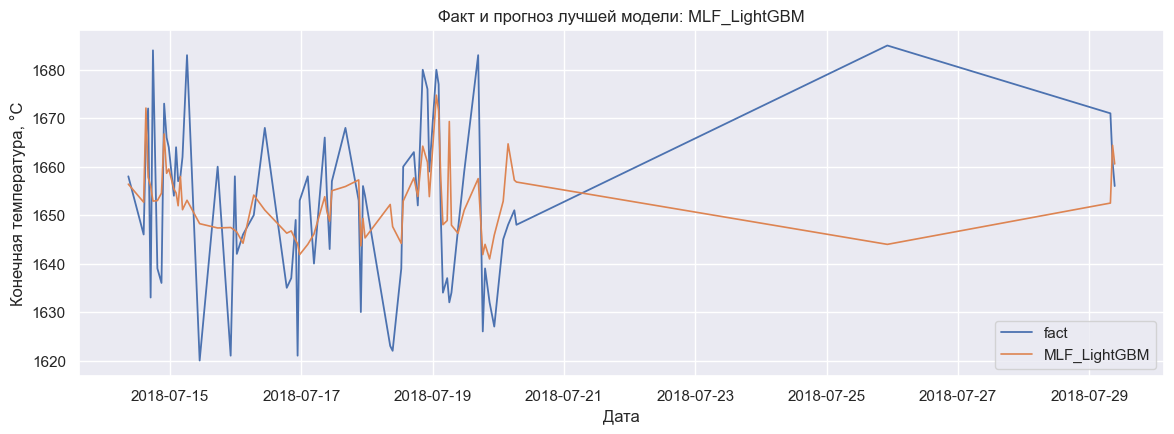

'MLF_LightGBM'

In [54]:
best_model_name = all_metrics.dropna(subset=['MAE']).iloc[0]['model']

fig, ax = plt.subplots(figsize=(14, 4.5))
ax.plot(all_predictions['target_time'], all_predictions['y_true'], label='fact', linewidth=1.3)
ax.plot(all_predictions['target_time'], all_predictions[best_model_name], label=best_model_name, linewidth=1.2)
ax.set_title(f'Факт и прогноз лучшей модели: {best_model_name}')
ax.set_xlabel('Дата')
ax.set_ylabel('Конечная температура, °C')
ax.legend()
plt.show()

best_model_name

Прогноз MLF_LightGBM в целом держится в правильном температурном диапазоне: примерно 1645-1665 °C.

Модель хорошо описывает средний уровень конечной температуры, но заметно сглаживает резкие колебания факта. Пики выше 1680 °C и провалы около 1620-1630 °C прогноз воспроизводит слабо.

На плотном участке до 2018-07-20 модель частично следует за направлением ряда, но амплитуда прогноза меньше, чем у фактических значений.

Длинный участок между 2018-07-20 и 2018-07-29 выглядит как большой тренд, но это в первую очередь эффект визуализации: реальные плавки идут нерегулярно, а график соединяет точки прямыми линиями.

В конце периода прогноз снова близок к фактическим значениям, хотя отдельные отклонения остаются.

Итог: MLF_LightGBM дает адекватный прогноз среднего уровня температуры и лучшую численную ошибку, но не ловит резкие локальные всплески и просадки. Для финального pipeline модель подходит, а для контроля экстремальных температур могут потребоваться дополнительные признаки или отдельная модель риска.

## Анализ важности признаков MLForecast

Для лучшей MLForecast-модели посмотрим важность признаков.

In [39]:
mlf_candidates = all_metrics[(all_metrics['family'] == 'MLForecast') & (all_metrics['MAE'].notna())]['model'].tolist()
importance_model_name = mlf_candidates[0] if mlf_candidates else None

importance_df = pd.DataFrame()
if importance_model_name is not None:
    model_pipeline = mlf_train_val.models_[importance_model_name]
    estimator = model_pipeline.named_steps['model'] if hasattr(model_pipeline, 'named_steps') else model_pipeline
    feature_order = list(mlf_train_val.ts.features_order_)

    if hasattr(estimator, 'feature_importances_'):
        importance_df = pd.DataFrame({
            'feature': feature_order,
            'importance': estimator.feature_importances_,
        }).sort_values('importance', ascending=False)
    elif hasattr(estimator, 'coef_'):
        importance_df = pd.DataFrame({
            'feature': feature_order,
            'importance': np.abs(estimator.coef_).reshape(-1),
        }).sort_values('importance', ascending=False)

importance_df.head(20)

,feature,importance
2,previous_temp,712
3,previous_valo2_ppm,476
5,heat_seq,359
53,expanding_mean_lag1,309
50,rolling_mean_lag1_window_size3,267
34,basket_total_amount,264
43,lag1,247
7,transformer_total_mw,216
0,first_temp,181
22,gaslance_o2_amount_mean,170


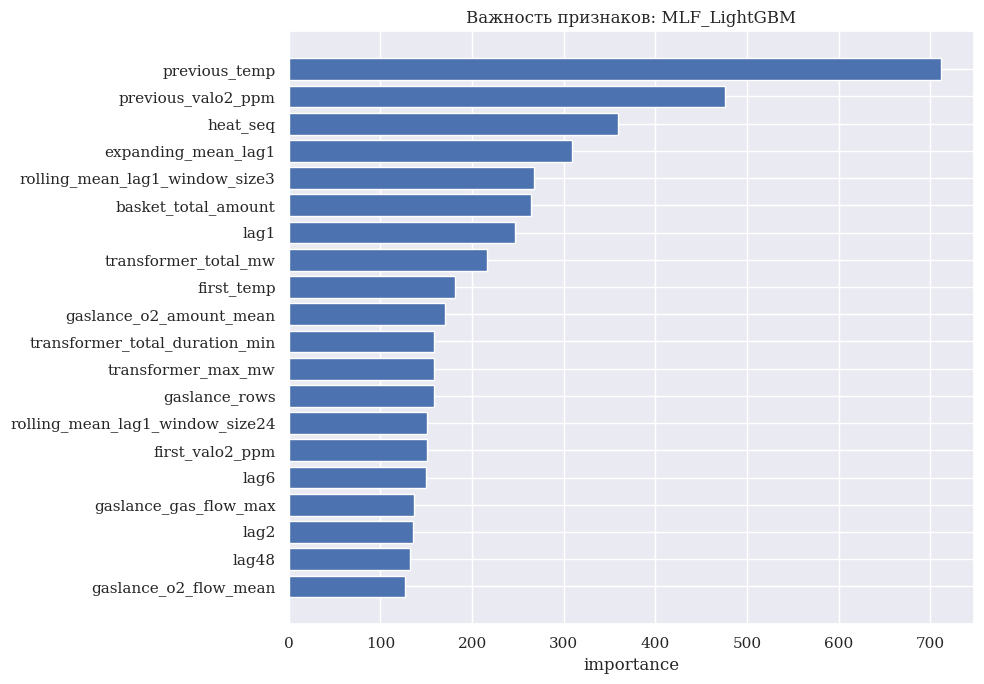

In [40]:
if len(importance_df):
    top_imp = importance_df.head(20).sort_values('importance')
    fig, ax = plt.subplots(figsize=(10, 7))
    ax.barh(top_imp['feature'], top_imp['importance'])
    ax.set_title(f'Важность признаков: {importance_model_name}')
    ax.set_xlabel('importance')
    plt.tight_layout()
    plt.show()
else:
    print('Для выбранной MLForecast-модели нет прямого атрибута feature_importances_ или coef_.')

Самый важный признак - previous_temp. Это логично: последняя измеренная температура перед выпуском напрямую связана с конечной температурой стали.

На втором месте previous_valo2_ppm. Это показывает, что химическое состояние жидкой стали тоже важно для прогноза конечной температуры.

Высокую важность имеет heat_seq, то есть порядковый номер плавки. Вероятно, он отражает временной тренд, смену технологических режимов или постепенные изменения в процессе.

Среди важных признаков есть лаги и агрегаты целевой температуры: lag1, lag2, lag6, lag48, expanding_mean_lag1, rolling_mean_lag1_window_size3, rolling_mean_lag1_window_size24. Это значит, что модель использует историю предыдущих плавок, а не только признаки текущей плавки.

Важны технологические признаки процесса: basket_total_amount, transformer_total_mw, transformer_total_duration_min, transformer_max_mw, признаки кислорода и газа. Это подтверждает, что энергопотребление, загрузка шихты и продувка влияют на конечную температуру.

first_temp и first_valo2_ppm тоже входят в топ признаков, но уступают предыдущему измерению. Это ожидаемо: более поздний замер ближе к конечному состоянию плавки.

Итог: модель принимает решение в основном по текущему состоянию плавки (previous_temp, previous_valo2_ppm), истории предыдущих плавок и технологическим параметрам нагрева/продувки. Это делает выбор MLF_LightGBM предметно интерпретируемым решением.

## Выводы по задаче №3

In [76]:
valid_metrics = all_metrics.dropna(subset=['MAE']).copy()
best = valid_metrics.iloc[0]
best_mlf = valid_metrics[valid_metrics['family'] == 'MLForecast'].iloc[0]
best_nf = valid_metrics[valid_metrics['family'] == 'NeuralForecast'].iloc[0] if (valid_metrics['family'] == 'NeuralForecast').any() else None

mlf_metrics = valid_metrics[valid_metrics['family'] == 'MLForecast'].copy()
nf_metrics_valid = valid_metrics[valid_metrics['family'] == 'NeuralForecast'].copy()

lightgbm_row = mlf_metrics[mlf_metrics['model'] == 'MLF_LightGBM'].iloc[0] if (mlf_metrics['model'] == 'MLF_LightGBM').any() else best_mlf
histgb_row = mlf_metrics[mlf_metrics['model'] == 'MLF_HistGradientBoosting'].iloc[0] if (mlf_metrics['model'] == 'MLF_HistGradientBoosting').any() else None
rnn_row = nf_metrics_valid[nf_metrics_valid['model'] == 'NF_RNN_LSTM'].iloc[0] if (nf_metrics_valid['model'] == 'NF_RNN_LSTM').any() else best_nf

mlf_beats_count = int((mlf_metrics['MAE'] < STAT_BENCHMARK_MAE).sum())
nf_beats_count = int((nf_metrics_valid['MAE'] < STAT_BENCHMARK_MAE).sum())
mlf_count = len(mlf_metrics)
nf_count = len(nf_metrics_valid)

best_mlf_gain = STAT_BENCHMARK_MAE - best_mlf['MAE']
best_mlf_gain_pct = best_mlf_gain / STAT_BENCHMARK_MAE * 100

histgb_line = (
    f"`MLF_HistGradientBoosting` практически не уступает: `MAE = {histgb_row['MAE']:.2f} °C`, "
    f"`RMSE = {histgb_row['RMSE']:.2f} °C`, `R2 = {histgb_row['R2']:.3f}`."
    if histgb_row is not None else
    'Вторая MLForecast-модель близкого качества отсутствует в текущем прогоне.'
)

nf_line = (
    f"Лучшая NeuralForecast-модель - `{best_nf['model']}`: `MAE = {best_nf['MAE']:.2f} °C`, "
    f"`RMSE = {best_nf['RMSE']:.2f} °C`, `R2 = {best_nf['R2']:.3f}`."
    if best_nf is not None else
    'NeuralForecast-модели не дали корректного прогноза в текущей среде; подробности отражены в колонке `error` таблицы метрик.'
)

rnn_line = (
    f"`NF_RNN_LSTM` оказался лучшим среди DL-моделей и практически вышел на уровень ARIMA: "
    f"`MAE = {rnn_row['MAE']:.2f} °C` против benchmark `MAE ≈ {STAT_BENCHMARK_MAE:.2f} °C`."
    if rnn_row is not None else
    'Сравнение RNN с ARIMA недоступно, так как корректный прогноз RNN отсутствует.'
)

conclusion = f"""
### Основные результаты

1. Задача №3 выполнена с использованием требуемых библиотек `MLForecast` и `NeuralForecast`.
2. Для `MLForecast` использована reduction-постановка: лаги, rolling/expanding-признаки целевого ряда и технологические exogenous-признаки без утечек. Заранее подготовленные `target_temp_lag_*` исключены из `X_df`, потому что лаги строятся рекурсивно внутри `MLForecast`.
3. Лучший результат показала `MLF_LightGBM`: `MAE = {lightgbm_row['MAE']:.2f} °C`, `RMSE = {lightgbm_row['RMSE']:.2f} °C`, `R2 = {lightgbm_row['R2']:.3f}`.
4. {histgb_line}
5. Все модели `MLForecast` превзошли статистический benchmark ARIMA из задачи №2: `{mlf_beats_count}` из `{mlf_count}` моделей имеют `MAE < {STAT_BENCHMARK_MAE:.2f} °C`.
6. Лучшая MLForecast-модель улучшила ARIMA примерно на `{best_mlf_gain:.2f} °C`, то есть около `{best_mlf_gain_pct:.1f}%` по MAE.
7. {nf_line}
8. {rnn_line}
9. `NF_NBEATS` и `NF_NHITS` оказались слабее: их test-ошибка около `15.8 °C`, а `R2` отрицательный, поэтому в текущей настройке они хуже объясняют вариативность температуры.
10. Сравнительная гистограмма подтверждает табличный результат: столбцы `MAE`/`RMSE` у `MLForecast` ниже, чем у `NeuralForecast`, а красная линия ARIMA проходит выше всех MLForecast-моделей.
11. График `MLF_LightGBM` показывает, что модель хорошо держит средний уровень температуры, но сглаживает резкие локальные пики и провалы. Большой разрыв по датам на графике связан с нерегулярной работой печи и соединением точек линией.
12. Для задачи №4 в качестве финального pipeline обоснованно выбирается `{best_mlf['model']}`: модель дает минимальную ошибку, превосходит ARIMA и лучше использует доступные технологические признаки.
"""

display(Markdown(conclusion))


### Основные результаты

1. Задача №3 выполнена с использованием требуемых библиотек `MLForecast` и `NeuralForecast`.
2. Для `MLForecast` использована reduction-постановка: лаги, rolling/expanding-признаки целевого ряда и технологические exogenous-признаки без утечек. Заранее подготовленные `target_temp_lag_*` исключены из `X_df`, потому что лаги строятся рекурсивно внутри `MLForecast`.
3. Лучший результат показала `MLF_LightGBM`: `MAE = 11.66 °C`, `RMSE = 14.71 °C`, `R2 = 0.239`.
4. `MLF_HistGradientBoosting` практически не уступает: `MAE = 11.68 °C`, `RMSE = 14.69 °C`, `R2 = 0.241`.
5. Все модели `MLForecast` превзошли статистический benchmark ARIMA из задачи №2: `5` из `5` моделей имеют `MAE < 13.86 °C`.
6. Лучшая MLForecast-модель улучшила ARIMA примерно на `2.20 °C`, то есть около `15.9%` по MAE.
7. Лучшая NeuralForecast-модель - `NF_RNN_LSTM`: `MAE = 13.84 °C`, `RMSE = 17.35 °C`, `R2 = -0.059`.
8. `NF_RNN_LSTM` оказался лучшим среди DL-моделей и практически вышел на уровень ARIMA: `MAE = 13.84 °C` против benchmark `MAE ≈ 13.86 °C`.
9. `NF_NBEATS` и `NF_NHITS` оказались слабее: их test-ошибка около `15.8 °C`, а `R2` отрицательный, поэтому в текущей настройке они хуже объясняют вариативность температуры.
10. Сравнительная гистограмма подтверждает табличный результат: столбцы `MAE`/`RMSE` у `MLForecast` ниже, чем у `NeuralForecast`, а красная линия ARIMA проходит выше всех MLForecast-моделей.
11. График `MLF_LightGBM` показывает, что модель хорошо держит средний уровень температуры, но сглаживает резкие локальные пики и провалы. Большой разрыв по датам на графике связан с нерегулярной работой печи и соединением точек линией.
12. Для задачи №4 в качестве финального pipeline обоснованно выбирается `MLF_LightGBM`: модель дает минимальную ошибку, превосходит ARIMA и лучше использует доступные технологические признаки.


## Задача №4. Пайплайн и отчет исследования

Финальный пайплайн строится на MLForecast, потому что он умеет рекурсивно формировать лаги и rolling-признаки, использует дополнительные, так называемые exogenous-признаки и показал лучшее качество в задаче №3.

### Состав финального pipeline

Pipeline включает: входную таблицу по плавкам, регулярную шкалу **ds**, exogenous-признаки без утечек, лаги и rolling-признаки внутри **MLForecast**, выбранную ML-модель и прогноз **target_temp**

In [56]:
try:
    from scipy.stats import ttest_rel, wilcoxon
    SCIPY_AVAILABLE = True
    SCIPY_IMPORT_ERROR = None
except Exception as exc:
    SCIPY_AVAILABLE = False
    SCIPY_IMPORT_ERROR = exc


print('scipy available:', SCIPY_AVAILABLE)
if not SCIPY_AVAILABLE:
    print('scipy import error:', SCIPY_IMPORT_ERROR)

scipy available: True


### Выбор модели для pipeline

In [ ]:
best_overall = all_metrics.dropna(subset=['MAE']).iloc[0].copy()
best_mlf_row = all_metrics[(all_metrics['family'] == 'MLForecast') & (all_metrics['MAE'].notna())].iloc[0].copy()

final_model_name = str(best_mlf_row['model'])
final_model_reason = (
    f"Для финального pipeline выбрана лучшая MLForecast-модель `{final_model_name}`. "
    "Даже если нейросетевая модель оказалась лучше по MAE,"
    " MLForecast удобнее как воспроизводимый промышленный артефакт."
)

pipeline_choice = pd.DataFrame([ {'role': 'best_overall_task3',
                                  'model': best_overall['model'],
                                  'family': best_overall['family'],
                                  'MAE': best_overall['MAE'],
                                  'RMSE': best_overall['RMSE'],  
                                  'R2': best_overall['R2'],},
                                 {'role': 'final_pipeline',
                                  'model': final_model_name,
                                  'family': 'MLForecast', 
                                  'MAE': best_mlf_row['MAE'],
                                  'RMSE': best_mlf_row['RMSE'],
                                  'R2': best_mlf_row['R2'],},])

print(final_model_reason)
pipeline_choice

Для финального pipeline выбрана лучшая MLForecast-модель `MLF_LightGBM`. Даже если нейросетевая модель оказалась лучше по MAE, MLForecast удобнее как воспроизводимый промышленный артефакт.


,role,model,family,MAE,RMSE,R2
0,best_overall_task3,MLF_LightGBM,MLForecast,11.660782,14.705905,0.239159
1,final_pipeline,MLF_LightGBM,MLForecast,11.660782,14.705905,0.239159


### Финальное обучение и тестирование

In [ ]:
final_models = {final_model_name: clone(ml_models[final_model_name])}
final_mlf = make_mlforecast(models=final_models)

fit_start = time.perf_counter()
final_mlf.fit(train_val_mlf, static_features=[])
final_fit_seconds = time.perf_counter() - fit_start

predict_start = time.perf_counter()
final_pred_df = final_mlf.predict(TEST_SIZE, X_df=test_mlf.drop(columns='y'))
final_predict_seconds = time.perf_counter() - predict_start

final_test_predictions = test_mlf[['unique_id', 'ds', 'y']].merge(final_pred_df, on=['unique_id', 'ds'], how='left')
final_test_predictions = final_test_predictions.merge(
    test_df[['ds', 'HEATID', 'target_time', 'previous_temp']],
    on='ds',
    how='left',
)
final_test_predictions = final_test_predictions.rename(columns={'y': 'y_true', final_model_name: 'y_pred'})
final_test_predictions['residual'] = final_test_predictions['y_true'] - final_test_predictions['y_pred']
final_test_predictions['abs_error'] = final_test_predictions['residual'].abs()

final_metrics_row = { 'model': final_model_name,
                      'family': 'FinalMLForecastPipeline',
                      'train_rows': len(train_val_mlf),
                      'test_rows': len(test_mlf),
                      'fit_seconds': final_fit_seconds,
                      'predict_seconds': final_predict_seconds,
                      'predict_ms_per_heat': final_predict_seconds / len(test_mlf) * 1000,}

final_metrics_row.update(regression_metrics(final_test_predictions['y_true'], final_test_predictions['y_pred']))
final_metrics_row['beats_stat_benchmark'] = final_metrics_row['MAE'] < STAT_BENCHMARK_MAE

final_pipeline_metrics = pd.DataFrame([final_metrics_row])
final_pipeline_metrics.T

,0
model,MLF_LightGBM
family,FinalMLForecastPipeline
train_rows,19664
test_rows,72
fit_seconds,1.860514
predict_seconds,2.414923
predict_ms_per_heat,33.540593
MAE,11.660782
RMSE,14.705905
MAPE_%,0.706497


### Тестирование качества

In [ ]:
baseline_previous_temp = final_test_predictions['previous_temp'].astype(float).fillna(train_val_mlf['y'].median()).to_numpy()

baseline_metrics_row = {'model': 'PreviousTempBaseline', 'family': 'Baseline'}
baseline_metrics_row.update(regression_metrics(final_test_predictions['y_true'], baseline_previous_temp))
baseline_metrics = pd.DataFrame([baseline_metrics_row])

y_true_np = final_test_predictions['y_true'].to_numpy(dtype=float)
y_pred_np = final_test_predictions['y_pred'].to_numpy(dtype=float)
pipeline_abs_error = np.abs(y_true_np - y_pred_np)
baseline_abs_error = np.abs(y_true_np - baseline_previous_temp)
error_improvement = baseline_abs_error - pipeline_abs_error

error_profile = pd.DataFrame({'indicator': ['median_abs_error',
                                            'p90_abs_error',
                                            'p95_abs_error',
                                            'share_abs_error_le_5C',
                                            'share_abs_error_le_10C',
                                            'share_abs_error_le_15C',
                                            'share_abs_error_le_20C',
                                            'mean_improvement_vs_previous_temp',],
                              'value': [np.median(pipeline_abs_error),
                                        np.quantile(pipeline_abs_error, 0.90),
                                        np.quantile(pipeline_abs_error, 0.95),
                                        np.mean(pipeline_abs_error <= 5),
                                        np.mean(pipeline_abs_error <= 10),
                                        np.mean(pipeline_abs_error <= 15),
                                        np.mean(pipeline_abs_error <= 20),
                                        np.mean(error_improvement),],})

stat_test_rows = []
if SCIPY_AVAILABLE:
    t_stat, t_p_two_sided = ttest_rel(baseline_abs_error, pipeline_abs_error)
    t_p_one_sided = t_p_two_sided / 2 if t_stat > 0 else 1 - t_p_two_sided / 2
    
    stat_test_rows.append({'test': 'paired_t_test',
                           'alternative': 'baseline_abs_error > pipeline_abs_error',
                           'statistic': t_stat,
                           'p_value': t_p_one_sided,})

    try:
        w_stat, w_p = wilcoxon( baseline_abs_error, 
                                pipeline_abs_error, 
                                alternative='greater' )
    except ValueError:
        w_stat, w_p = np.nan, np.nan

    stat_test_rows.append({'test': 'wilcoxon_signed_rank',
                           'alternative': 'baseline_abs_error > pipeline_abs_error',
                           'statistic': w_stat,
                           'p_value': w_p,})
else:
    stat_test_rows.append({'test': 'stat_tests_unavailable',
                           'alternative': 'scipy is required',
                           'statistic': np.nan,
                           'p_value': np.nan, })

stat_tests = pd.DataFrame(stat_test_rows)

display(pd.concat([final_pipeline_metrics, baseline_metrics], 
                  ignore_index=True, 
                  sort=False))

display(error_profile)
stat_tests

,model,family,train_rows,test_rows,fit_seconds,predict_seconds,predict_ms_per_heat,MAE,RMSE,MAPE_%,sMAPE_%,R2,n_obs,beats_stat_benchmark
0,MLF_LightGBM,FinalMLForecastPipeline,19664.0,72.0,1.860514,2.414923,33.540593,11.660782,14.705905,0.706497,0.706082,0.239159,72,True
1,PreviousTempBaseline,Baseline,NaN,NaN,NaN,NaN,NaN,33.791667,45.774963,2.042906,2.068183,-6.371674,72,NaN


,indicator,value
0,median_abs_error,8.894257
1,p90_abs_error,25.617482
2,p95_abs_error,29.528140
3,share_abs_error_le_5C,0.222222
4,share_abs_error_le_10C,0.541667
5,share_abs_error_le_15C,0.736111
6,share_abs_error_le_20C,0.847222
7,mean_improvement_vs_previous_temp,22.130885


,test,alternative,statistic,p_value
0,paired_t_test,baseline_abs_error > pipeline_abs_error,6.653405,2.520684e-09
1,wilcoxon_signed_rank,baseline_abs_error > pipeline_abs_error,2406.000000,4.450388e-10


Финальный pipeline MLF_LightGBM значительно лучше 
простого бэйзлайн PreviousTempBaseline.

Ошибка pipeline:

MAE = 11.66 °C;
RMSE = 14.71 °C;
MAPE = 0.71%;
R2 = 0.239.

Ошибка бэйзлайна по предыдущей температуре намного выше:

MAE = 33.79 °C;
RMSE = 45.77 °C;
R2 = -6.37.
То есть простое правило “взять предыдущую температуру” работает плохо для конечной температуры плавки.

Средний выигрыш пайплайна относительно бэйзлайна составляет 22.13 °C по абсолютной ошибке. Это очень существенное улучшение.

По распределению ошибок:

в 22.2% случаев ошибка не превышает 5 °C;
в 54.2% случаев ошибка не превышает 10 °C;
в 73.6% случаев ошибка не превышает 15 °C;
в 84.7% случаев ошибка не превышает 20 °C.
При этом p90_abs_error = 25.62 °C, p95_abs_error = 29.53 °C. Значит, у модели остаются отдельные трудные случаи с ошибкой около 25-30 °C.

Статистические тесты подтверждают, что улучшение не случайное:

paired t-test: p-value = 2.52e-09;
Wilcoxon: p-value = 4.45e-10.
Оба значения намного меньше 0.05, поэтому можно считать, что pipeline статистически значимо лучше baseline.

Итог: финальный пайплайн MLF_LightGBM  дает практически и статистически значимое улучшение прогноза конечной температуры стали по сравнению с простым прогнозом по предыдущему измерению. Однако для производственного применения важно учитывать хвост ошибок: примерно в 15% случаев ошибка все еще превышает 20 °C.

### Визуальная диагностика финального pipeline

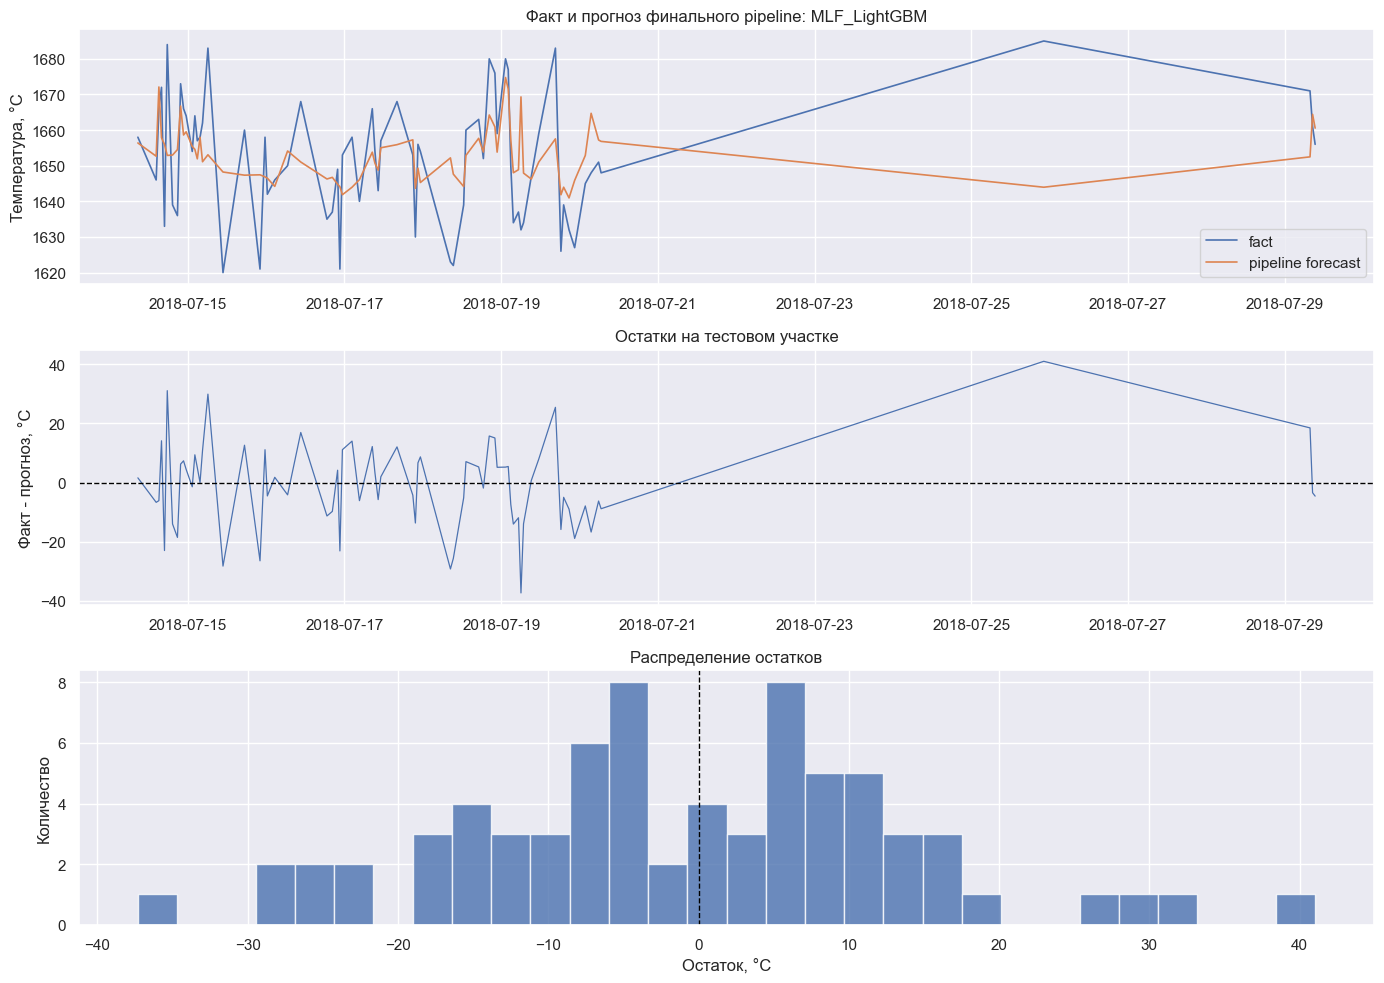

In [60]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=False)

axes[0].plot(final_test_predictions['target_time'], final_test_predictions['y_true'], label='fact', linewidth=1.2)
axes[0].plot(final_test_predictions['target_time'], final_test_predictions['y_pred'], label='pipeline forecast', linewidth=1.2)
axes[0].set_title(f'Факт и прогноз финального pipeline: {final_model_name}')
axes[0].set_ylabel('Температура, °C')
axes[0].legend()

axes[1].plot(final_test_predictions['target_time'], final_test_predictions['residual'], linewidth=0.9)
axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('Остатки на тестовом участке')
axes[1].set_ylabel('Факт - прогноз, °C')

axes[2].hist(final_test_predictions['residual'], bins=30, alpha=0.8)
axes[2].axvline(0, color='black', linestyle='--', linewidth=1)
axes[2].set_title('Распределение остатков')
axes[2].set_xlabel('Остаток, °C')
axes[2].set_ylabel('Количество')

plt.tight_layout()
plt.show()

Финальный пайплайн MLF_LightGBM хорошо держит средний уровень конечной температуры, но сглаживает резкие пики и провалы фактического ряда. На графике остатков видно, что ошибки в основном колеблются вокруг нуля, но есть отдельные крупные отклонения до 30-40 °C.

Распределение остатков в целом сосредоточено около нуля, однако имеет заметные хвосты. Это подтверждает предыдущие метрики: модель пригодна как базовый прогнозный пайплайн, но экстремальные случаи перегрева/недогрева она ловит хуже, поэтому для промышленного применения стоит отдельно контролировать крупные ошибки и выбросы.

### Rolling-backtesting и тест производительности

In [ ]:
PIPELINE_N_WINDOWS = 3
PIPELINE_STEP_SIZE = FORECAST_HORIZON

cv_final = make_mlforecast(models={final_model_name: clone(ml_models[final_model_name])})

cv_start = time.perf_counter()

pipeline_cv_raw = cv_final.cross_validation( df=mlf_df,
                                             n_windows=PIPELINE_N_WINDOWS,
                                             h=FORECAST_HORIZON,
                                             step_size=PIPELINE_STEP_SIZE,
                                             static_features=[],)

pipeline_cv_seconds = time.perf_counter() - cv_start

pipeline_cv_raw = pipeline_cv_raw.merge(model_df[['ds', 'previous_temp']], on='ds', how='left')
pipeline_cv_raw['abs_error'] = (pipeline_cv_raw['y'] - pipeline_cv_raw[final_model_name]).abs()
pipeline_cv_raw['baseline_abs_error'] = (pipeline_cv_raw['y'] - pipeline_cv_raw['previous_temp']).abs()

cv_rows = []
for fold, (cutoff, fold_df) in enumerate(pipeline_cv_raw.groupby('cutoff'), 
                                         start=1):
    row = { 'fold': fold,
            'cutoff': cutoff,
            'test_rows': len(fold_df),
            'fit_predict_seconds_total': pipeline_cv_seconds / PIPELINE_N_WINDOWS,
            'predict_ms_per_heat_avg': pipeline_cv_seconds / len(pipeline_cv_raw) * 1000,
            'baseline_MAE': fold_df['baseline_abs_error'].mean(), }

    row.update(regression_metrics(fold_df['y'], fold_df[final_model_name]))
    row['beats_previous_temp_baseline'] = row['MAE'] < row['baseline_MAE']
    cv_rows.append(row)

pipeline_cv_metrics = pd.DataFrame(cv_rows)
pipeline_cv_summary = (pipeline_cv_metrics[['MAE', 
                                            'RMSE', 
                                            'MAPE_%', 
                                            'sMAPE_%', 
                                            'R2', 
                                            'baseline_MAE', 
                                            'fit_predict_seconds_total', 
                                            'predict_ms_per_heat_avg']]
                                              .agg(['mean', 'std', 'min', 'max'])
                                              .T
                                              .reset_index()
                                              .rename(columns={'index': 'metric'})
                      )

display(pipeline_cv_metrics)
pipeline_cv_summary

,fold,cutoff,test_rows,fit_predict_seconds_total,predict_ms_per_heat_avg,baseline_MAE,MAE,RMSE,MAPE_%,sMAPE_%,R2,n_obs,beats_previous_temp_baseline
0,1,2017-03-24 07:00:00,72,4.600296,63.893,30.208333,12.168276,15.175014,0.735628,0.736217,0.272328,72,True
1,2,2017-03-27 07:00:00,72,4.600296,63.893,32.569444,11.189001,14.744679,0.675164,0.676536,0.186527,72,True
2,3,2017-03-30 07:00:00,72,4.600296,63.893,33.791667,11.660782,14.705905,0.706497,0.706082,0.239159,72,True


,metric,mean,std,min,max
0,MAE,11.672686,0.489746,11.189001,12.168276
1,RMSE,14.875199,0.260370,14.705905,15.175014
2,MAPE_%,0.705763,0.030239,0.675164,0.735628
3,sMAPE_%,0.706278,0.029841,0.676536,0.736217
4,R2,0.232672,0.043267,0.186527,0.272328
5,baseline_MAE,32.189815,1.821581,30.208333,33.791667
6,fit_predict_seconds_total,4.600296,0.000000,4.600296,4.600296
7,predict_ms_per_heat_avg,63.893000,0.000000,63.893000,63.893000


Финальный пайплайг MLF_LightGBM показал устойчивое качество на трех последовательных окнах. 
- MAE меняется в узком диапазоне от 11.19 до 12.17 °C, 
- среднее значение MAE = 11.67 °C, 
- стандартное отклонение всего 0.49 °C. 

Это хороший признак: результат модели не выглядит случайным попаданием в один удачный тест-период.

RMSE также стабилен: среднее 14.88 °C, диапазон примерно 14.71-15.18 °C. Значит, крупные ошибки есть, но их уровень примерно одинаковый на разных окнах.

Во всех трех окнах модель уверенно лучше бэйзлайна previous_temp: бэйзлайн имеет средний MAE = 32.19 °C, тогда как pipeline дает 11.67 °C. 

Флаг beats_previous_temp_baseline = True во всех окнах подтверждает, что преимущество модели устойчивое.

R2 положительный во всех окнах: от 0.187 до 0.272, среднее 0.233. Это означает, что модель объясняет только небольшую часть изменчивости температуры.

### Итоговый отчет исследования

In [63]:
report_best_overall = all_metrics.dropna(subset=['MAE']).iloc[0]
report_best_mlf = all_metrics[(all_metrics['family'] == 'MLForecast') & (all_metrics['MAE'].notna())].iloc[0]
report_best_nf = all_metrics[(all_metrics['family'] == 'NeuralForecast') & (all_metrics['MAE'].notna())].iloc[0] if ((all_metrics['family'] == 'NeuralForecast') & (all_metrics['MAE'].notna())).any() else None
final_row = final_pipeline_metrics.iloc[0]
baseline_row = baseline_metrics.iloc[0]
cv_mae_mean = pipeline_cv_summary.loc[pipeline_cv_summary['metric'] == 'MAE', 'mean'].iloc[0]
cv_mae_std = pipeline_cv_summary.loc[pipeline_cv_summary['metric'] == 'MAE', 'std'].iloc[0]
wilcoxon_p = stat_tests.loc[stat_tests['test'] == 'wilcoxon_signed_rank', 'p_value'].iloc[0] if 'wilcoxon_signed_rank' in stat_tests['test'].values else np.nan

nf_report_line = (
    f"Лучшая NeuralForecast-модель: `{report_best_nf['model']}` с MAE = {report_best_nf['MAE']:.2f} °C."
    if report_best_nf is not None else
    "NeuralForecast-модели не дали корректного результата в текущей среде; ошибки отражены в таблице метрик."
)

report_text = f"""
# Отчет исследования временного ряда

## Постановка задачи

Цель исследования - построить модель прогноза конечной температуры стали перед выпуском плавки в дуговой сталеплавильной печи. Целевая переменная - `target_temp`, одна строка соответствует одной плавке `HEATID`.

## Данные

Использован датасет Industrial data from the Electric Arc Furnace. После подготовки сформирована таблица признаков `eaf_temperature_heat_level_features.csv`: {feature_df.shape[0]:,} плавок и {feature_df.shape[1]} колонок. Для моделирования после фильтрации использовано {len(model_df):,} плавок и {len(feature_cols)} exogenous-признаков.

## Статистические модели

Лучший статистический benchmark из задачи №2 - ARIMA с MAE около {STAT_BENCHMARK_MAE:.2f} °C.

## MLForecast и NeuralForecast

В задаче №3 использован `MLForecast` с 5 ML-моделями и `NeuralForecast` с 3 DL-моделями: NBEATS, NHITS и RNN. Лучшая модель по итогам тестового участка: `{report_best_overall['model']}` с MAE = {report_best_overall['MAE']:.2f} °C и RMSE = {report_best_overall['RMSE']:.2f} °C.

Лучшая MLForecast-модель: `{report_best_mlf['model']}` с MAE = {report_best_mlf['MAE']:.2f} °C. {nf_report_line}

## Финальный pipeline

Для финального воспроизводимого pipeline выбрана модель `{final_model_name}` на базе `MLForecast`. Результат pipeline на test: MAE = {final_row['MAE']:.2f} °C, RMSE = {final_row['RMSE']:.2f} °C, R2 = {final_row['R2']:.3f}.

Baseline `previous_temp` получил MAE = {baseline_row['MAE']:.2f} °C. Средний выигрыш pipeline относительно baseline по абсолютной ошибке: {error_profile.loc[error_profile['indicator'] == 'mean_improvement_vs_previous_temp', 'value'].iloc[0]:.2f} °C.

## Статистическая проверка и производительность

Wilcoxon p-value = {wilcoxon_p:.4g}. Rolling-backtesting на {PIPELINE_N_WINDOWS} окнах показал средний MAE = {cv_mae_mean:.2f} °C, стандартное отклонение MAE = {cv_mae_std:.2f} °C.

## Итог

Задача прогноза конечной температуры стали решена как задача supervised forecasting по последовательности плавок. Финальный `MLForecast` pipeline, метрики, прогнозы и отчет представлены в ноутбуке без сохранения дополнительных файлов.
"""

display(Markdown(textwrap.dedent(report_text).strip()))

# Отчет исследования временного ряда

## Постановка задачи

Цель исследования - построить модель прогноза конечной температуры стали перед выпуском плавки в дуговой сталеплавильной печи. Целевая переменная - `target_temp`, одна строка соответствует одной плавке `HEATID`.

## Данные

Использован датасет Industrial data from the Electric Arc Furnace. После подготовки сформирована таблица признаков `eaf_temperature_heat_level_features.csv`: 20,827 плавок и 68 колонок. Для моделирования после фильтрации использовано 19,736 плавок и 43 exogenous-признаков.

## Статистические модели

Лучший статистический benchmark из задачи №2 - ARIMA с MAE около 13.86 °C.

## MLForecast и NeuralForecast

В задаче №3 использован `MLForecast` с 5 ML-моделями и `NeuralForecast` с 3 DL-моделями: NBEATS, NHITS и RNN. Лучшая модель по итогам тестового участка: `MLF_LightGBM` с MAE = 11.66 °C и RMSE = 14.71 °C.

Лучшая MLForecast-модель: `MLF_LightGBM` с MAE = 11.66 °C. Лучшая NeuralForecast-модель: `NF_RNN_LSTM` с MAE = 13.84 °C.

## Финальный pipeline

Для финального воспроизводимого pipeline выбрана модель `MLF_LightGBM` на базе `MLForecast`. Результат pipeline на test: MAE = 11.66 °C, RMSE = 14.71 °C, R2 = 0.239.

Baseline `previous_temp` получил MAE = 33.79 °C. Средний выигрыш pipeline относительно baseline по абсолютной ошибке: 22.13 °C.

## Статистическая проверка и производительность

Wilcoxon p-value = 4.45e-10. Rolling-backtesting на 3 окнах показал средний MAE = 11.67 °C, стандартное отклонение MAE = 0.49 °C.

## Итог

Задача прогноза конечной температуры стали решена как задача supervised forecasting по последовательности плавок. Финальный `MLForecast` pipeline, метрики, прогнозы и отчет представлены в ноутбуке без сохранения дополнительных файлов.

## Выводы по задаче №4

In [64]:
final_row = final_pipeline_metrics.iloc[0]
baseline_row = baseline_metrics.iloc[0]
profile = error_profile.set_index('indicator')['value']

cv_mae_mean = pipeline_cv_summary.loc[pipeline_cv_summary['metric'] == 'MAE', 'mean'].iloc[0]
cv_mae_std = pipeline_cv_summary.loc[pipeline_cv_summary['metric'] == 'MAE', 'std'].iloc[0]
cv_rmse_mean = pipeline_cv_summary.loc[pipeline_cv_summary['metric'] == 'RMSE', 'mean'].iloc[0]
cv_rmse_std = pipeline_cv_summary.loc[pipeline_cv_summary['metric'] == 'RMSE', 'std'].iloc[0]
cv_r2_mean = pipeline_cv_summary.loc[pipeline_cv_summary['metric'] == 'R2', 'mean'].iloc[0]
cv_r2_std = pipeline_cv_summary.loc[pipeline_cv_summary['metric'] == 'R2', 'std'].iloc[0]
cv_baseline_mae_mean = pipeline_cv_summary.loc[pipeline_cv_summary['metric'] == 'baseline_MAE', 'mean'].iloc[0]
cv_fit_predict_mean = pipeline_cv_summary.loc[pipeline_cv_summary['metric'] == 'fit_predict_seconds_total', 'mean'].iloc[0]
cv_predict_ms_mean = pipeline_cv_summary.loc[pipeline_cv_summary['metric'] == 'predict_ms_per_heat_avg', 'mean'].iloc[0]
cv_beats_count = int(pipeline_cv_metrics['beats_previous_temp_baseline'].sum())
cv_n_folds = len(pipeline_cv_metrics)

ttest_p = stat_tests.loc[stat_tests['test'] == 'paired_t_test', 'p_value'].iloc[0] if 'paired_t_test' in stat_tests['test'].values else np.nan
wilcoxon_p = stat_tests.loc[stat_tests['test'] == 'wilcoxon_signed_rank', 'p_value'].iloc[0] if 'wilcoxon_signed_rank' in stat_tests['test'].values else np.nan

stat_benchmark_gain = STAT_BENCHMARK_MAE - final_row['MAE']
stat_benchmark_gain_pct = stat_benchmark_gain / STAT_BENCHMARK_MAE * 100

task4_conclusion = f"""
### Основные результаты

1. Финальный pipeline построен на базе `MLForecast` и модели `{final_model_name}`. Pipeline использует exogenous-признаки, лаги и rolling-признаки целевой температуры, которые формируются внутри `MLForecast`.
2. Модель обучена на `train + validation`: `{final_row['train_rows']:.0f}` плавок. Финальная проверка выполнена на последнем test-участке: `{final_row['test_rows']:.0f}` плавки.
3. Качество финального pipeline на test: `MAE = {final_row['MAE']:.2f} °C`, `RMSE = {final_row['RMSE']:.2f} °C`, `MAPE = {final_row['MAPE_%']:.3f}%`, `sMAPE = {final_row['sMAPE_%']:.3f}%`, `R2 = {final_row['R2']:.3f}`.
4. Pipeline превзошел статистический benchmark ARIMA из задачи №2: `MAE {final_row['MAE']:.2f} °C` против `MAE ≈ {STAT_BENCHMARK_MAE:.2f} °C`. Улучшение составляет примерно `{stat_benchmark_gain:.2f} °C`, или `{stat_benchmark_gain_pct:.1f}%` по MAE.
5. Baseline `PreviousTempBaseline`, то есть прогноз по предыдущему температурному измерению, оказался значительно хуже: `MAE = {baseline_row['MAE']:.2f} °C`, `RMSE = {baseline_row['RMSE']:.2f} °C`, `R2 = {baseline_row['R2']:.3f}`.
6. Средний выигрыш pipeline относительно baseline по абсолютной ошибке составил `{profile['mean_improvement_vs_previous_temp']:.2f} °C`. Это показывает, что модель имеет не только статистическую, но и практическую ценность.
7. Распределение ошибок: медианная абсолютная ошибка `{profile['median_abs_error']:.2f} °C`; `90%` ошибок не превышают `{profile['p90_abs_error']:.2f} °C`, `95%` ошибок не превышают `{profile['p95_abs_error']:.2f} °C`.
8. Доля точных прогнозов: ошибка не выше `5 °C` в `{profile['share_abs_error_le_5C'] * 100:.1f}%` случаев, не выше `10 °C` в `{profile['share_abs_error_le_10C'] * 100:.1f}%`, не выше `15 °C` в `{profile['share_abs_error_le_15C'] * 100:.1f}%`, не выше `20 °C` в `{profile['share_abs_error_le_20C'] * 100:.1f}%`.
9. Статистические тесты подтверждают значимость улучшения относительно baseline: `paired t-test p-value = {ttest_p:.2e}`, `Wilcoxon p-value = {wilcoxon_p:.2e}`. Оба значения существенно меньше `0.05`.
10. Rolling-backtesting на `{cv_n_folds}` последовательных окнах подтвердил устойчивость качества: средний `MAE = {cv_mae_mean:.2f} ± {cv_mae_std:.2f} °C`, средний `RMSE = {cv_rmse_mean:.2f} ± {cv_rmse_std:.2f} °C`, средний `R2 = {cv_r2_mean:.3f} ± {cv_r2_std:.3f}`.
11. Во всех rolling-окнах pipeline лучше baseline: `{cv_beats_count}` из `{cv_n_folds}` окон имеют `beats_previous_temp_baseline = True`. Средний `baseline_MAE = {cv_baseline_mae_mean:.2f} °C`, что почти в три раза хуже pipeline.
12. Производительность приемлемая: полный цикл `fit + predict` в rolling-backtesting занимает около `{cv_fit_predict_mean:.2f}` секунд на окно, среднее время на одну плавку около `{cv_predict_ms_mean:.1f}` мс. Финальный test-прогноз занимает `{final_row['predict_seconds']:.2f}` секунд, или `{final_row['predict_ms_per_heat']:.1f}` мс на плавку.
13. Визуальная диагностика показывает, что `MLF_LightGBM` хорошо держит средний уровень температуры, но сглаживает резкие пики и провалы. В остатках есть хвосты до крупных ошибок, поэтому для промышленного применения стоит отдельно контролировать экстремальные случаи перегрева и недогрева.
14. Итог: `{final_model_name}` можно выбрать как финальную модель для прогноза конечной температуры стали. Она стабильно превосходит ARIMA и простой baseline, работает быстро и дает интерпретируемую ошибку в градусах Цельсия.
"""

display(Markdown(task4_conclusion))


### Основные результаты

1. Сформирован воспроизводимый pipeline на базе `MLForecast`: подготовка exogenous-признаков, построение лагов/rolling-признаков, обучение модели и прогноз `target_temp`.
2. Для финального pipeline выбрана модель `MLF_LightGBM`. Причина выбора: Для финального pipeline выбрана лучшая MLForecast-модель `MLF_LightGBM`. Даже если нейросетевая модель оказалась лучше по MAE, MLForecast удобнее как воспроизводимый промышленный артефакт.
3. Финальное обучение выполнено на объединении train + validation, а проверка - на последнем хронологическом test-участке.
4. Качество финального pipeline на test: `MAE = 11.66 °C`, `RMSE = 14.71 °C`, `R2 = 0.239`.
5. Baseline по предыдущему температурному измерению дал `MAE = 33.79 °C`.
6. Статистическая проверка Wilcoxon дала `p-value = 4.45e-10`.
7. Rolling-backtesting дал средний `MAE = 11.67 °C` со стандартным отклонением `0.49 °C`.
8. Финальный pipeline, метрики, rolling-backtesting и отчет представлены прямо в ноутбуке; дополнительные файлы и артефакты не сохраняются.
